# Clustering: Concept Overview

Clustering is an **unsupervised learning** technique that groups data points based on their similarity. It helps uncover hidden structures or patterns in datasets without using predefined labels.

## Goal of Clustering

- Discover **natural groupings** in the data.
- Reduce complexity.
- Prepare for **visualization** or further analysis.


## Types of Clustering Algorithms

### 1. **Centroid-Based Clustering (e.g., K-Means)**
- Clusters are formed around **centroids** (center points).
- Each data point is assigned to the nearest centroid.
- Requires predefining the number of clusters `k`.
- Works best when clusters are **spherical** and **similar in size**.

Example: K-Means

### 2. **Hierarchical Clustering**
- Builds a **tree of clusters** (called a dendrogram).
- Two main types:
  - **Agglomerative**: bottom-up (start with individual points, merge).
  - **Divisive**: top-down (start with all data, split iteratively).
- Does not require setting `k` in advance; dendrogram can be "cut" at any level.

Example: Agglomerative Clustering

### 3. **Density-Based Clustering (e.g., DBSCAN)**
- Groups together points in **dense regions**, marks low-density points as **outliers**.
- Does **not** require number of clusters.
- Good for detecting clusters of **arbitrary shapes** and handling noise.

Parameters:
- `eps`: neighborhood radius
- `min_samples`: minimum points to form a dense region

### Clustering Activity: Iris Dataset

In this activity, we will explore **unsupervised learning** using the classic **Iris dataset**. Our goal is to apply clustering algorithms like **K-Means** to discover natural groupings in the data, without using the known species labels.

### Loading Datasets from `sklearn.datasets`

Many datasets in `scikit-learn` (like Iris, Wine, Breast Cancer, etc.) are provided as dictionary-like objects with the following common structure:

- `.data` → Feature matrix (NumPy array)
- `.target` → Labels or classes (NumPy array)
- `.feature_names` → List of column names for `.data`
- `.target_names` → Class names corresponding to `.target` values
- `.DESCR` → Text description of the dataset

These can be easily converted into a pandas DataFrame for exploration and modeling.

### Load the Dataset
Load the Iris dataset and preview the first five rows to understand the structure.

In [ ]:
# YOUR CODE HERE

### Extract Features
Remove the class label column and keep only numeric features for clustering.

In [ ]:
# YOUR CODE HERE

### Check the Distributions

Before clustering, it's helpful to **visualize the distributions** of each feature.  
Plot histograms for all four features in the Iris dataset and observe their ranges and shapes.

In [ ]:
# YOUR CODE HERE

## A Side Step: Make It Reusable

We will use this histogram code later to compare feature distributions **before and after scaling**.  
Instead of repeating histogram code, wrap it in a **reusable function**.  

In [ ]:
# YOUR CODE HERE
def plot_feature_dists(X, feature_names, title_prefix=""):
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    for i, (row, col) in enumerate(positions):
        axes[row][col].hist(X[:, i], bins=20, edgecolor='black')
        axes[row][col].set_title(f"{title_prefix}{feature_names[i]}")

    plt.tight_layout()
    plt.show()

You can definitely write this more general to work with every dataset and an arbitrary number of columns.  
But we kept it simple.

### Do we need scaling here?

### Why Scale the Data?

Many clustering algorithms (like K-Means) are **distance-based**, so features with larger scales can dominate.  
We scale the data to give all features equal influence — try clustering with and without scaling to see the difference!

### Apply StandardScaler
Standardize the features to have zero mean and unit variance.

In [ ]:
# YOUR CODE HERE

### Visualize Standard Scaling Effect
Plot histograms after standard scaling.

In [ ]:
# YOUR CODE HERE

After scaling, all features should have **similar ranges** (centered around 0, with unit variance),  
regardless of their original spread. This makes distance-based clustering more reliable.

### Try Min-Max Scaling
Now rescale the features to a 0–1 range using MinMaxScaler and visualize the result.

In [ ]:
# YOUR CODE HERE

### Visualize Standard Scaling Effect
Plot histograms after Min-Max scaling.

In [ ]:
# YOUR CODE HERE

### Apply K-Means Clustering
Cluster the scaled data using K-Means with 3 clusters (the known number of Iris species).

In [ ]:
# YOUR CODE HERE

### Visualize Clusters (2D)
Create a scatter plot of the data using two features (e.g., sepal length vs. petal length), colored by cluster labels.

In [ ]:
# YOUR CODE HERE

### Inspect Cluster Centers

After fitting K-Means, check the **cluster centers** in both the **scaled** and **original** feature space.

- First, print the scaled cluster centers to see where the algorithm positioned the centroids in standardized units.
- Then, use `scaler.inverse_transform()` to convert those centers back to the **original scale** — this makes them easier to interpret in terms of real-world feature values (like centimeters for sepal length).

In [ ]:
# YOUR CODE HERE

### Visualize Cluster Centers
Overlay cluster centers (in original scale) on the same scatter plot.

In [ ]:
plt.scatter(x[:, 0], x[:, 2], c=kmeans.labels_, s=40, edgecolor='black')
plt.scatter(centers[:, 0], centers[:, 2], s=350, marker='*', c='red', edgecolor='black')
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Clusters with Centers")
plt.show()

### DBSCAN Clustering

Unlike K-Means, DBSCAN doesn't require the number of clusters in advance.  
It groups together **dense regions** of points and marks low-density points as **noise** (`-1` label).

Try DBSCAN on the scaled Iris data using reasonable `eps` and `min_samples` values.

- `eps` controls the **neighborhood radius** — how close points need to be to be considered part of a cluster. (use eps=0.15)
- `min_samples` is the **minimum number of neighbors** a point needs to form a dense region. (use min_samples=5)

In [ ]:
# YOUR CODE HERE

### Visualize DBSCAN Clusters

Plot two features (e.g., sepal length vs petal length) and color by DBSCAN labels.  
Notice how noise points are labeled `-1` and appear as a separate group.

In [ ]:
# YOUR CODE HERE

### Let's plot it better to show the noise clearly

In [ ]:
# YOUR CODE HERE
unique_labels = np.unique(labels)
plt.figure(figsize=(8, 6))

for i in range(len(unique_labels)):
    label = unique_labels[i]
    mask = labels == label
    label_name = f"Cluster {label}" if label != -1 else "Noise"
    plt.scatter(x[mask, 0], x[mask, 2], s=40, c=f"C{i}", label=label_name, edgecolor='black')

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

### Which Worked Better? K-Means or DBSCAN

Now that you've visualized the clustering results:

**Think about:**
- Did DBSCAN identify useful clusters?
- Were any points marked as noise that seemed meaningful?
- Which method better reflects the natural groupings in the Iris data?

In this case, **K-Means** tends to perform better because the Iris dataset has well-separated, compact clusters.  
**DBSCAN** still adds value by detecting possible boundary points and outliers.

### A Side Step: Comparing K-Means and DBSCAN on Synthetic Data

To better understand how **K-Means** and **DBSCAN** behave in different situations, let's create two synthetic datasets and apply both algorithms to them.

- First, we'll generate **concentric circles** using `make_circles` to see how each method handles non-linear, non-convex clusters.
- Then, we'll use `make_blobs` to create more traditional Gaussian clusters with different spreads.

For tight shapes like **circles**, try a **small `eps`** (e.g., `0.2`).  
For more spread-out blobs, use a **larger `eps`** (e.g., `0.9`).

First use:

```python
from sklearn.datasets import make_circles
Xsynth, _ = make_circles(n_samples=500, factor=0.5, noise=0.05)

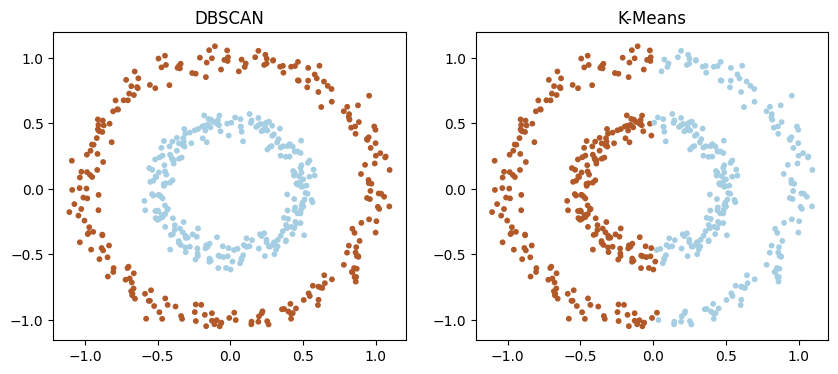

In [2]:
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

Xsynth, _ = make_circles(n_samples=500, factor=0.5, noise=0.05)

# Apply clustering
kmeans = KMeans(n_clusters=2, random_state=0).fit(Xsynth)
dbscan = DBSCAN(eps=0.2, min_samples=5).fit(Xsynth)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(Xsynth[:, 0], Xsynth[:, 1], c=dbscan.labels_, cmap='Paired', s=10)
ax1.set_title("DBSCAN")
ax2.scatter(Xsynth[:, 0], Xsynth[:, 1], c=kmeans.labels_, cmap='Paired', s=10)
ax2.set_title("K-Means")
plt.show()


Now use:

```python
from sklearn.datasets import make_blobs
Xsynth, _ = make_blobs(n_samples=500, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=0)


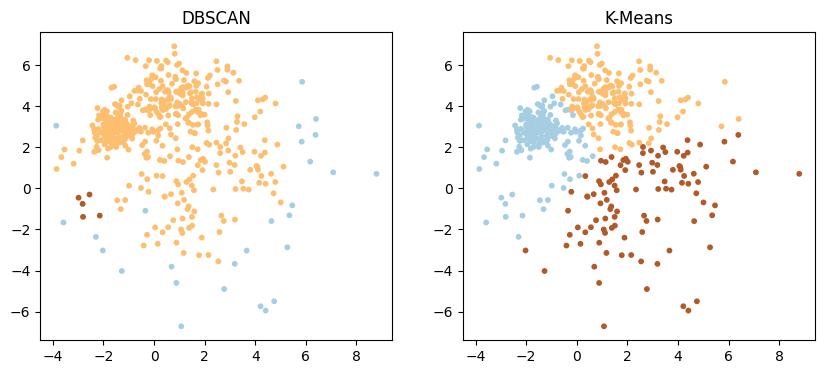

In [3]:
from sklearn.datasets import make_blobs

# Generate blobs with uneven densities
Xsynth, _ = make_blobs(n_samples=500, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=0)

# Apply clustering
kmeans = KMeans(n_clusters=3, random_state=0).fit(Xsynth)
dbscan = DBSCAN(eps=0.9, min_samples=5).fit(Xsynth)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(Xsynth[:, 0], Xsynth[:, 1], c=dbscan.labels_, cmap='Paired', s=10)
ax1.set_title("DBSCAN")
ax2.scatter(Xsynth[:, 0], Xsynth[:, 1], c=kmeans.labels_, cmap='Paired', s=10)
ax2.set_title("K-Means")
plt.show()

### Let's Get Back to the Iris Dataset

Now that you've seen how clustering algorithms behave on synthetic data, let's return to the **Iris dataset**.

We'll apply **Hierarchical Clustering** and visualize the results using a **dendrogram** to understand how the algorithm builds clusters step by step.

You can experiment with different linkage methods like `"single"`, `"complete"`, or `"ward"` to see how they affect the clustering structure.

### Hierarchical Clustering on Iris

We'll start by computing the pairwise distances between points, then build the cluster tree using different **linkage methods**.

Try both the **scaled** and **original** versions of the data, and observe how it affects the structure of the dendrogram.

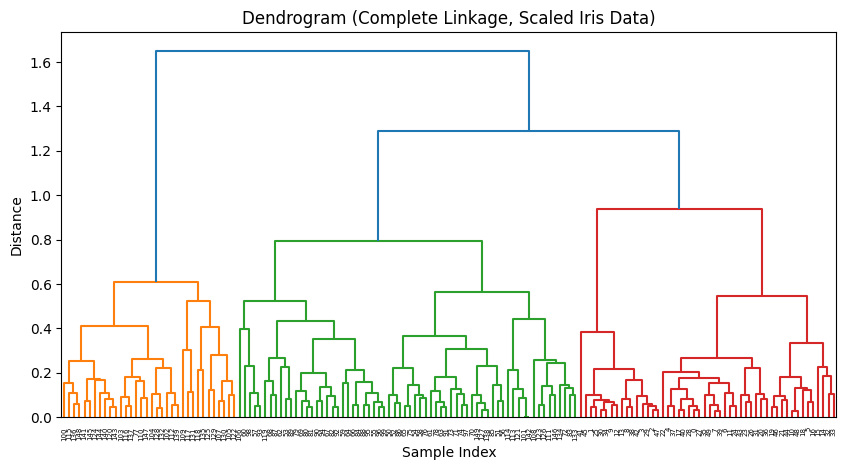

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Perform hierarchical clustering directly on scaled data
linked = linkage(x_scal, method='complete')  # or 'ward', 'single', etc.

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram (Complete Linkage, Scaled Iris Data)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.grid(False)
plt.show()

### Try with Original Features

Now use the same clustering method on the **original, unscaled** data.  
See how the dendrogram structure changes based on the feature scales.

In [ ]:
# YOUR CODE HERE

### Try Different Linkage Methods

Try replacing `"complete"` with `"single"` or `"ward"` to see how the clustering behavior changes.  
Some methods are more sensitive to outliers or chaining effects.

In [ ]:
# YOUR CODE HERE

### Dimensionality Reduction

When working with datasets that have multiple features, it's often useful to **reduce the number of dimensions** while keeping the core structure of the data.

This helps with:
- **Visualization** (especially in 2D or 3D)
- **Noise reduction**
- Improving performance of clustering or other algorithms

We’ll explore two popular methods:

#### PCA (Principal Component Analysis)
- A **linear** technique that projects data onto new axes (principal components).
- Captures the **maximum variance** in fewer dimensions.
- Great for understanding **global structure** and for interpretability.


#### t-SNE (t-Distributed Stochastic Neighbor Embedding)
- A **non-linear** technique that focuses on preserving **local relationships**.
- Excellent for visualizing **clusters** or substructures.
- More sensitive to parameters like `perplexity`, and computationally heavier.

### PCA: Principal Component Analysis

Let's reduce the 4D Iris data to **2 principal components** to capture the majority of its variance in a 2D space.

This helps us **visualize natural groupings** and see how much structure PCA can preserve.

In [ ]:
# YOUR CODE HERE
from sklearn.decomposition import PCA

# Fit PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scal)

# Plot the 2D PCA projection
plt.figure(figsize=(8, 5))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=df['class'], cmap='viridis', s=40)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Iris Dataset")
plt.show()

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

### t-SNE: Non-Linear Dimensionality Reduction

t-SNE is a powerful technique for visualizing high-dimensional data in 2D by preserving **local structure**.

Let’s apply it to the Iris dataset and compare the layout to PCA.

In [ ]:
# If you see lots of warnings and it is annoying, uncomment the following lines and run!

# import warnings
# warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
from sklearn.manifold import TSNE

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_scal)

# Plot t-SNE projection
plt.figure(figsize=(8, 5))
plt.scatter(x_tsne[:, 0], x_tsne[:, 1], c=df['class'], cmap='viridis', s=40)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Projection of Iris Dataset")
plt.show()

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Grouping FIFA Players by Skillset

We’ll use **PCA** to reduce the dimensions of FIFA player stats and then apply **K-Means clustering** to group similar players.

This gives us a visual summary of how top players relate to one another based on their skill profiles.

**The code is partly given. Complete the rest.**

#### 1. Load the FIFA Dataset  
- Use the dataset `players_20.csv`.  
- Filter players with an **overall rating > 86** to focus on elite players.  
- Save the player names for later annotation.

In [ ]:
import pandas as pd
df = pd.read_csv("players_20.csv")
df = df[df['overall'] > 86]
names = df['short_name'].values

#### 2. Clean the Data  
- Keep **only numeric features**.  
- Fill in missing values using column means.

In [ ]:
# Drop non-numeric and ID columns
df_numeric = df.select_dtypes(include=[np.number])

# Handle missing values (YOUR CODE HERE)
# YOUR CODE HERE

#### 3. Scale the Features  
- Use **MinMaxScaler** to normalize all numeric values to the range [0, 1].

In [ ]:
# Scale the features
# YOUR CODE HERE

#### 4. Apply PCA  
- Reduce the dimensions to **2 principal components** for visualization.  
- This helps project player attributes into a 2D space while preserving structure.

In [ ]:
# Apply PCA
# YOUR CODE HERE

#### 5. Apply K-Means Clustering on the result of PCA
- Choose a reasonable number of clusters — typically **4 to 6** makes sense (goalkeepers, defenders, midfielders, attackers, etc.).  
- Use `KMeans(n_clusters=5)` as a starting point.

In [ ]:
# Apply KMeans
# YOUR CODE HERE

#### 6. Visualize Results  
- Create a scatter plot of the PCA components.  
- Color-code by cluster and **label each point with the player's name**.  
- Reflect on the groupings — are players with similar roles ending up in the same cluster?

**Adjust the names of variables in the following code if you chose other names.**

In [ ]:
import seaborn as sns

# Create a DataFrame for plotting
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['Cluster'] = clusters
plot_df['Name'] = names

plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Cluster', s=150, palette='tab10', legend=False)

# Add player names as annotations
for i in range(len(plot_df)):
    plt.text(plot_df['PC1'][i], plot_df['PC2'][i], plot_df['Name'][i], fontsize=9)

plt.title("FIFA Players Grouped by Skillset (PCA + KMeans)", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(False)
plt.show()